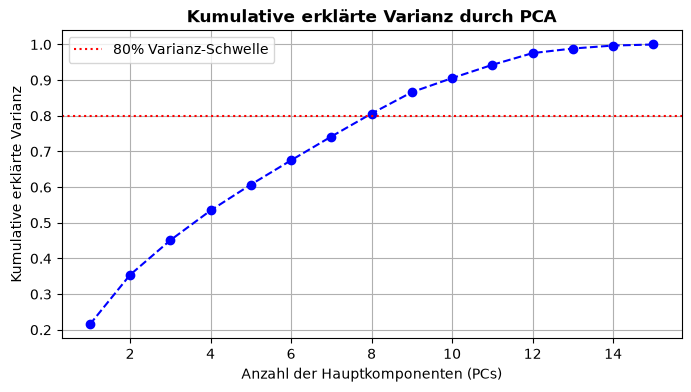

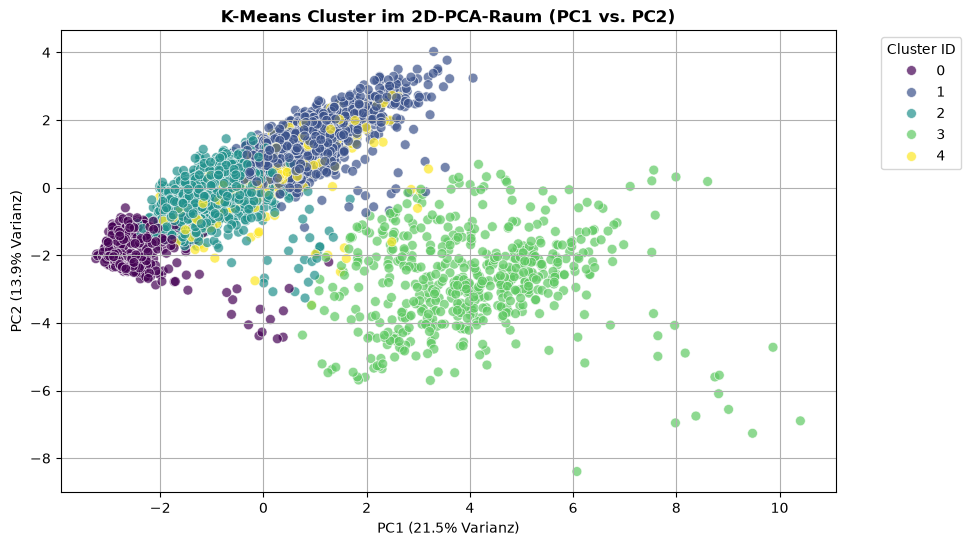

Erklärte Varianz durch PC1 & PC2: 35.40%


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Skalierte Daten laden & IDs entfernen
df_scaled = pd.read_csv('../data/traveltide_features_scaled.csv')
X = df_scaled.drop(columns=['user_id'])

# 2. PCA initialisieren (Anzahl der Komponenten = originale Feature-Anzahl für die Varianz-Analyse)
pca_full = PCA()
pca_full.fit(X)

# Kumulative erklärte Varianz berechnen
cum_explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Plot der kumulativen erklärten Varianz (Scree Plot)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--', color='b')
plt.title('Kumulative erklärte Varianz durch PCA', fontweight='bold')
plt.xlabel('Anzahl der Hauptkomponenten (PCs)')
plt.ylabel('Kumulative erklärte Varianz')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Varianz-Schwelle')
plt.grid(True)
plt.legend()

os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/pca_explained_variance.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. PCA auf 2 Komponenten für die 2D-Visualisierung reduzieren
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

# 5. K-Means (K=5) ausführen und mit PCA visualisieren
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_scaled['cluster'] = kmeans.fit_predict(X)

# DataFrame für Seaborn Scatterplot erstellen
df_pca_plot = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_plot['cluster'] = df_scaled['cluster']

# Visualisierung der Cluster im 2D-Raum
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca_plot,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title('K-Means Cluster im 2D-PCA-Raum (PC1 vs. PC2)', fontweight='bold')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Varianz)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Varianz)')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.savefig('../reports/figures/cluster_pca_2d_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Erklärte Varianz durch PC1 & PC2: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")